Saving Dataset (1).csv to Dataset (1) (2).csv
✅ Dataset loaded.
Columns: ['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']
   Aggregate rating                          Cuisines              City  \
0               4.8        French, Japanese, Desserts       Makati City   
1               4.5                          Japanese       Makati City   
2               4.4  Seafood, Asian, Filipino, Indian  Mandaluyong City   
3               4.9                   Japanese, Sushi  Mandaluyong City   
4               4.8                  Japanese, Korean  Mandaluyong City   

   Votes  Average Cost for two  
0    314                  1100  
1    591                  1200  
2    270                  4000  
3  

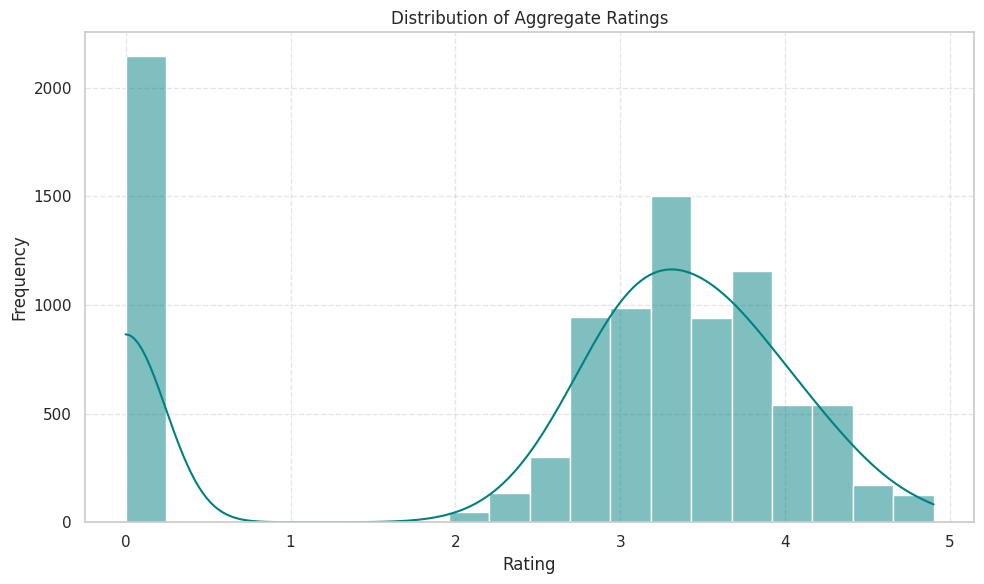

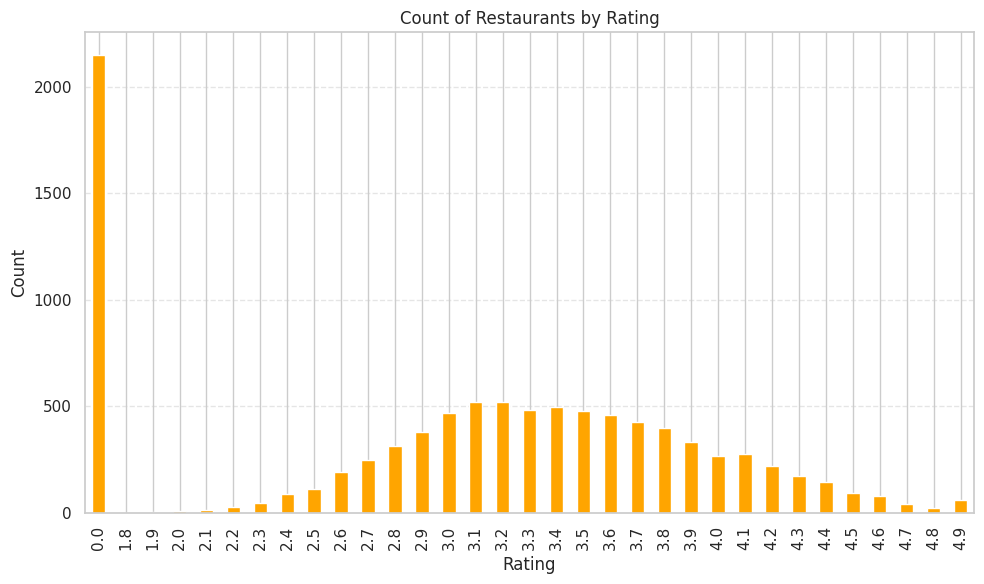

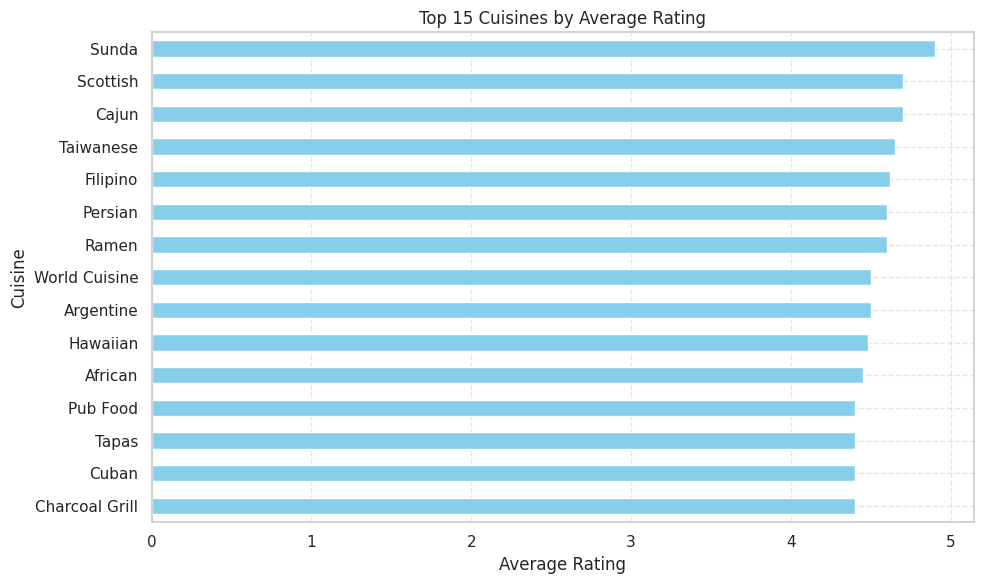

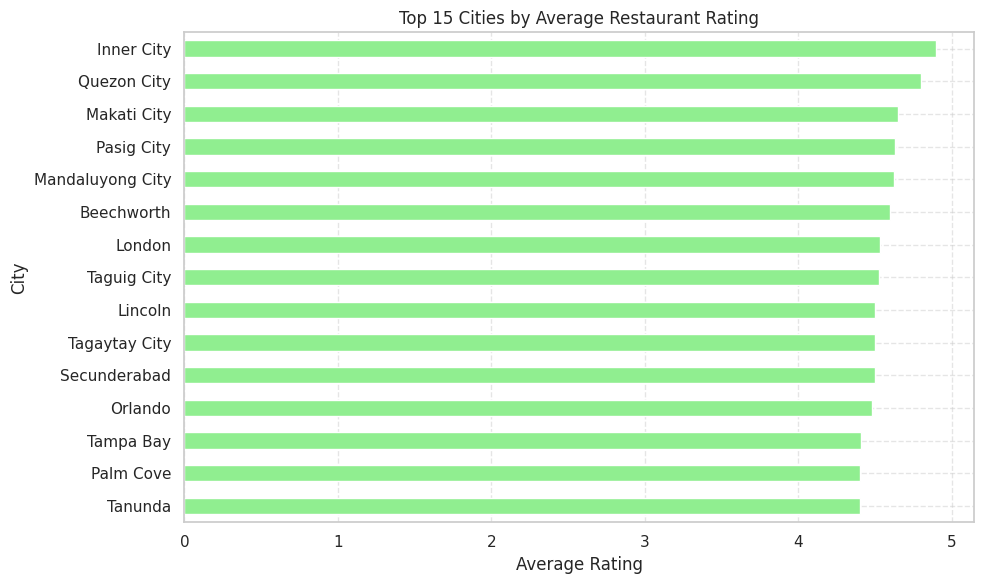

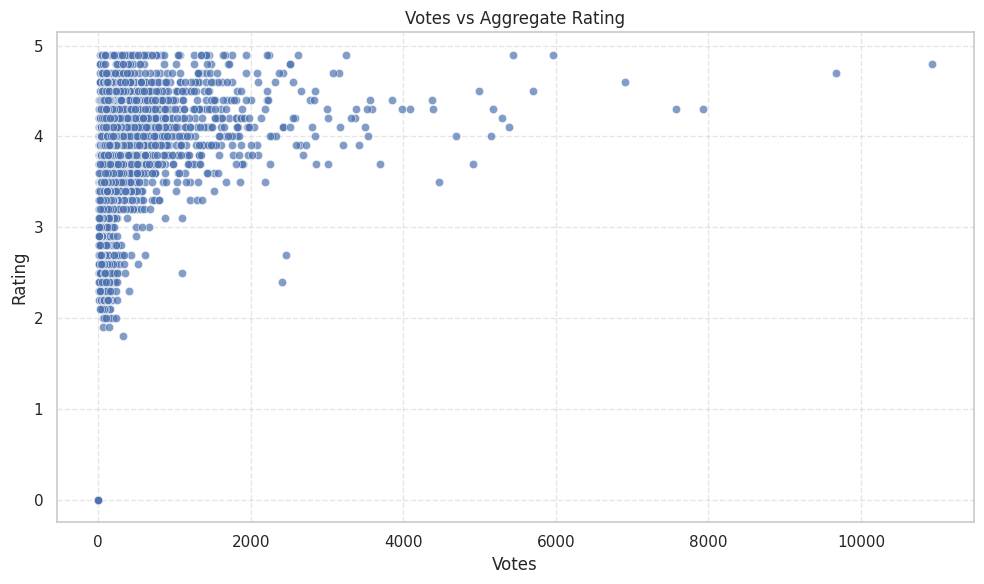

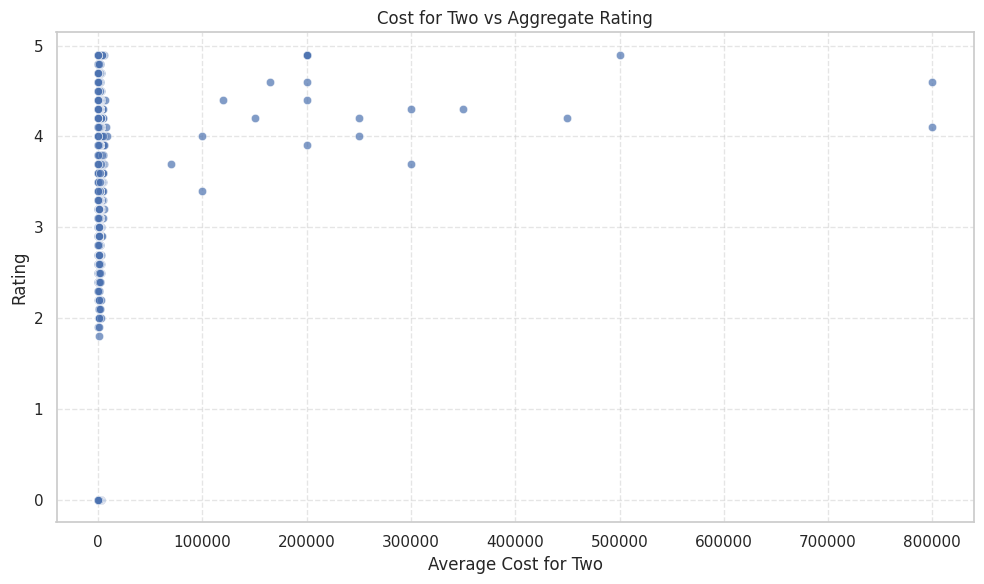

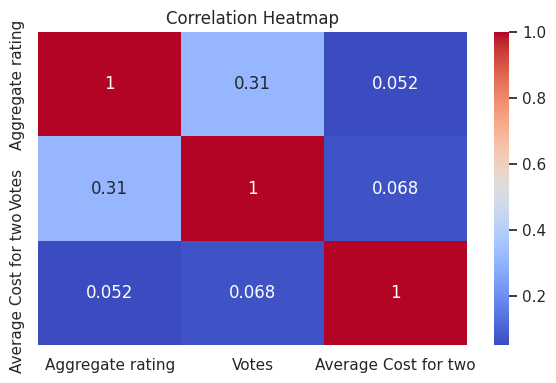

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print("✅ Dataset loaded.")
print("Columns:", df.columns.tolist())
print(df[['Aggregate rating', 'Cuisines', 'City', 'Votes', 'Average Cost for two']].head())

df = df[['Aggregate rating', 'Cuisines', 'City', 'Votes', 'Average Cost for two']].dropna()
df['Cuisines'] = df['Cuisines'].astype(str).apply(lambda x: x.split(',')[0].strip())


sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

plt.figure()
sns.histplot(df['Aggregate rating'], bins=20, kde=True, color='teal')
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
rating_counts = df['Aggregate rating'].value_counts().sort_index()
plt.figure()
rating_counts.plot(kind='bar', color='orange')
plt.title("Count of Restaurants by Rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
avg_rating_cuisine = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)

plt.figure()
avg_rating_cuisine.head(15).plot(kind='barh', color='skyblue')
plt.title("Top 15 Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
avg_rating_city = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

plt.figure()
avg_rating_city.head(15).plot(kind='barh', color='lightgreen')
plt.title("Top 15 Cities by Average Restaurant Rating")
plt.xlabel("Average Rating")
plt.ylabel("City")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure()
sns.scatterplot(data=df, x='Votes', y='Aggregate rating', alpha=0.7)
plt.title("Votes vs Aggregate Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.figure()
sns.scatterplot(data=df, x='Average Cost for two', y='Aggregate rating', alpha=0.7)
plt.title("Cost for Two vs Aggregate Rating")
plt.xlabel("Average Cost for Two")
plt.ylabel("Rating")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 4))
sns.heatmap(df[['Aggregate rating', 'Votes', 'Average Cost for two']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
